# Анализ лояльности пользователей Яндекс Афиши

Автор: Тулянцева Альбина
Дата выполнения: 21.02.2026

Цель проекта: провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно.

Задачи: 
1. Загрузить и предобработать данные
2. Создать профиль пользователя
3. Провести исследовательский анализ
4. Сделать выводы и рекомендации
5. Опубликовать проект в Git

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `...`:

- **Хост** — `...`
- **База данных** — `...`
- **Порт** — `...`
- **Аутентификация** — `...`
- **Пользователь** — `...`
- **Пароль** — `...`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [ ]:
#Установка нужных библиотек
!pip install phik -q
!pip install python-dotenv -q

#Импорт библитек
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from phik import phik_matrix

In [2]:
load_dotenv()
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
  os.getenv('DB_USER'),
  os.getenv('DB_PASSWORD'),
  os.getenv('DB_HOST'),
  os.getenv('DB_PORT'),
  os.getenv('DB_NAME'),
) 

In [3]:
engine = create_engine(connection_string)

query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT user_id, device_type_canonical, order_id, created_dt_msk AS order_dt, created_ts_msk AS order_ts, currency_code, revenue, tickets_count, EXTRACT(DAY FROM(created_dt_msk - LAG(created_dt_msk) OVER(PARTITION BY user_id ORDER BY created_dt_msk)))::INT AS days_since_prev, e.event_id, event_name_code AS event_name, service_name, event_type_main, region_name, city_name
FROM afisha.purchases AS p
JOIN afisha.events AS e ON p.event_id = e.event_id
JOIN afisha.city AS c ON e.city_id = c.city_id
JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE device_type_canonical IN ('desktop', 'mobile') AND event_type_main NOT IN ('фильм')
ORDER BY user_id
'''

In [4]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

In [6]:
df.describe()

,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,625.584360,2.754311,3.222381,438019.834992
std,2.497551e+06,1227.693064,1.170620,11.350509,147423.078841
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000


In [7]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


Во время изучения данных было выявлено, что в данных присутствует 290611 ненулевых строк. Пропуски встречаются в столбце days_since_prev, но в данном случае они уместны, так как эта покупка может быть первой у пользователя и предыдущей не существует.
Столбцы order_id и event_id можно перевести в тип object, чтобы они не взаимодейтсвовали с численными данными.
В столбце revenue встречаются большие выбросы, так как среднее значение значительно отличается от медианы, разброс максимального и минимального значений также большой. В столбце tickets_count данные распределены относительно равномерно. В столбце days_since_prev также есть большой разброс.
В данных заметно, что столбец с выручкой представлен в двух валютах: рубли и тенге. Для удобства работы в дальнейшем нужно все перевести в рубли. Также в дальнейшем нужно будет провести проверку на явные и неявные дубликаты, сменить типы данных на оптимальную размерность и проверить численные столбцы на аномальные значения.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [8]:
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [9]:
# Проверяем уникальные значения валют
df_tenge['cdx'].unique()

array(['kzt'], dtype=object)

In [10]:
# Проверка на пропуски
print("Пропуски в данных о курсах:")
print(df_tenge.isnull().sum())

# Проверка на дубликаты по датам
print(f"\nДубликаты дат: {df_tenge['data'].duplicated().sum()}")

# Проверка формата дат
df_tenge['data'] = pd.to_datetime(df_tenge['data']).dt.date
print(f"\nДиапазон дат: {df_tenge['data'].min()} - {df_tenge['data'].max()}")

# Проверка адекватности значений курса
print("\nСтатистика по курсу (на 100 тенге):")
print(df_tenge['curs'].describe())

# Проверка номинала
print(f"\nУникальные значения номинала: {df_tenge['nominal'].unique()}")

Пропуски в данных о курсах:
data       0
nominal    0
curs       0
cdx        0
dtype: int64

Дубликаты дат: 0

Диапазон дат: 2024-01-10 - 2024-12-31

Статистика по курсу (на 100 тенге):
count    357.000000
mean      19.755818
std        0.833798
min       17.848600
25%       19.120200
50%       19.876000
75%       20.443300
max       21.937100
Name: curs, dtype: float64

Уникальные значения номинала: [100]


В данных всего лишь 1 значение валюты, поэтому можно проводить конвертацию тенге в рубли. Пропуски и дубликаты в данных отсутствуют. Диапазоны дат соответвуют диапазонам в основном датафрейме. Медиана максимально приближена к среднему значению, значит аномальных выбросов в данных нет.

In [11]:
df_tenge['data'] = pd.to_datetime(df_tenge['data']).dt.date
df['order_dt'] = pd.to_datetime(df['order_dt']).dt.date

df = df.merge(df_tenge[['data', 'curs']], left_on='order_dt', right_on='data', how='left')

df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)

result_df = df[['user_id', 'currency_code', 'revenue', 'revenue_rub']]

print(f'Датафрейм с рублями:')
display(((result_df[result_df['currency_code'] == 'rub']).head()))


print(f'Датафрейм с тенге:')
display(((result_df[result_df['currency_code'] == 'kzt']).head()))

Датафрейм с рублями:


,user_id,currency_code,revenue,revenue_rub
0,0002849b70a3ce2,rub,1521.94,1521.94
1,0005ca5e93f2cf4,rub,289.45,289.45
2,0005ca5e93f2cf4,rub,1258.57,1258.57
3,000898990054619,rub,8.49,8.49
4,000898990054619,rub,1390.41,1390.41


Датафрейм с тенге:


,user_id,currency_code,revenue,revenue_rub
70,0033403583a55ed,kzt,518.10,98.503762
89,0040e12d70fae81,kzt,347.18,65.731589
96,0054b38b2653e6e,kzt,328.77,61.148261
277,00f4f5244501ce6,kzt,22021.55,4380.702898
460,01370a0e9c1a7d5,kzt,7397.66,1478.296591


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

# 2.2.1 Перевод в нужный тип данных

In [12]:
df['order_id'] = df['order_id'].astype('object')
df['event_id'] = df['event_id'].astype('object')

In [13]:
df['days_since_prev'] = df['days_since_prev'].astype('Int64')

In [14]:
df['device_type_canonical'] = df['device_type_canonical'].astype('category')
df['event_type_main'] = df['event_type_main'].astype('category')

# 2.2.2 Ищем дубликаты

In [15]:
df['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

In [16]:
user_order_duplicates = df.groupby(['user_id', 'order_id']).size().reset_index(name='count')
duplicates = user_order_duplicates[user_order_duplicates['count'] > 1]
if duplicates.empty:
    print('Дубликатов в связке user_id и order_id нет.')
else:
    print(f'Найдено дубликатов: {len(duplicates)} дубликатов user_id+order_id')
    print(duplicates.sort_values(['user_id', 'order_id']))

Дубликатов в связке user_id и order_id нет.


In [17]:
cols_to_check = ['user_id', 'order_ts', 'revenue']

# Находим дубликаты
duplicate_mask = df.duplicated(subset=cols_to_check, keep=False)

duplicates_df = df[duplicate_mask].sort_values(by=['user_id', 'order_ts'])
print(f"Найдено потенциально дублирующихся записей: {len(duplicates_df)}")

if len(duplicates_df) > 0:
    # Группируем по ключевым полям и считаем количество записей в группе
    duplicate_groups = duplicates_df.groupby(cols_to_check).size().reset_index(name='count')
    print("Распределение дублирующихся групп:")
    print(duplicate_groups['count'].value_counts())
    # Если видим много групп с count=2 - это дубли.
    
# Удаляем дубликаты, оставляя первое вхождение (keep='first')
# Сортируем по дате, чтобы "первый" был хронологически первым.
df_cleaned = df.sort_values(by=['user_id', 'order_ts']).drop_duplicates(subset=cols_to_check, keep='first')

deleted_ratio = round((((len(df) - len(df_cleaned))/len(df)) * 100), 3)

print(f"Было записей: {len(df)}. Стало после удаления дубликатов: {len(df_cleaned)}")
print(f"Относительное количество удаленных данных:{deleted_ratio} %")

df_cleaned = df_cleaned.sort_values(by=['user_id', 'order_ts']).copy()

# Убеждаемся, что колонка с датой имеет правильный тип datetime
df_cleaned['order_ts'] = pd.to_datetime(df_cleaned['order_ts'])

# Сначала вычисляем разницу (получаем Timedelta)
diff = df_cleaned.groupby('user_id')['order_ts'].diff()

# Извлекаем количество дней из Timedelta
df['days_since_prev'] = diff.dt.days

# Заполняем NaN и преобразуем в int
df['days_since_prev'] = df['days_since_prev'].astype(float)

Найдено потенциально дублирующихся записей: 99
Распределение дублирующихся групп:
2    45
3     3
Name: count, dtype: int64
Было записей: 290611. Стало после удаления дубликатов: 290560
Относительное количество удаленных данных:0.018 %


In [18]:
df['device_type_canonical'].unique()

['mobile', 'desktop']
Categories (2, object): ['mobile', 'desktop']

In [19]:
df['event_type_main'].unique()

['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Categories (7, object): ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']

In [20]:
df['region_name'].unique()

array(['Каменевский регион', 'Североярская область', 'Озернинский край',
       'Лугоградская область', 'Поленовский край', 'Широковская область',
       'Медовская область', 'Златопольский округ', 'Малиновоярский округ',
       'Яблоневская область', 'Ветренский регион', 'Боровлянский край',
       'Крутоводская область', 'Ягодиновская область',
       'Серебряноярский округ', 'Лесодальний край', 'Верхоречная область',
       'Горицветская область', 'Речиновская область', 'Травиницкий округ',
       'Сосновская область', 'Серебринская область', 'Травяная область',
       'Каменноярский край', 'Солнечноземская область',
       'Светополянский округ', 'Заречная область', 'Ручейковский край',
       'Глиногорская область', 'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
       'Зоринский регион', 'Берёзовская область', 'Лесостепной край',
       'Малиновая область', 'Синегорский регион', 'Луговая область',
       'Шанырский регион', 'Каменополянский окр

In [21]:
df['city_name'].unique()

array(['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск',
       'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай',
       'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич',
       'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск',
       'Серебрянка', 'Островецк', 'Родниковец', 'Дальнесветск',
       'Луговаярово', 'Дальнополин', 'Ягодиновка', 'Солчелуг', 'Озёрчане',
       'Серебровино', 'Лесоярово', 'Глинополье', 'Глиноград',
       'Дальнесветин', 'Северополье', 'Теплоозеро', 'Горнодолинск',
       'Ордакент', 'Озёрово', 'Луговинск', 'Лугоград', 'Златопольск',
       'Крутовинск', 'Сарыжар', 'Сосновечин', 'Тихоярск', 'Яблонецк',
       'Жаркентай', 'Широковка', 'Синеводов', 'Синеводск', 'Тихосветск',
       'Радужанов', 'Глиногорь', 'Каменосветск', 'Родниковск',
       'Травогород', 'Глинянск', 'Радужинск', 'Поляногорье',
       'Дальнолесье', 'Ручейник', 'Ключеград', 'Ключеводск', 'Поленовино',
       'Речичанск', 'Ключевополье', 'Шаныртау', 'Дальнесоснов'

## 2.2.3 Изучаем данные

In [22]:
if ((df['days_since_prev'].isna()) & (df['tickets_count'] != 1)).all():
    print(f'Ошибка в данных! Отсутствует количество дней с предыдущего заказа')
else:
    print(f'Количество дней с предыдущего заказа отсутствует только у первых заказов')

Количество дней с предыдущего заказа отсутствует только у первых заказов


Всего записей: 290611
Количество нулевых значений: 206724
Процент нулевых значений: 71.13%
Количество ненулевых значений: 83887
Процент ненулевых значений: 28.87%
Количество NaN: 21984


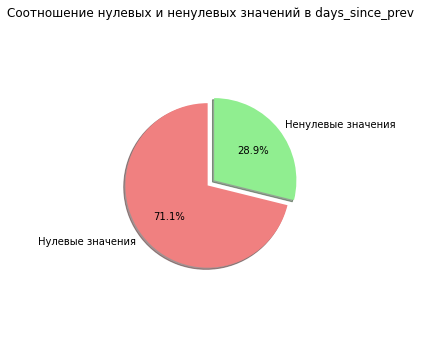

In [23]:
# Подсчет количества значений с нулем
total_count = len(df['days_since_prev'])
zero_count = (df['days_since_prev'] == 0).sum()
zero_percentage = (zero_count / total_count) * 100

print(f"Всего записей: {total_count}")
print(f"Количество нулевых значений: {zero_count}")
print(f"Процент нулевых значений: {zero_percentage:.2f}%")
print(f"Количество ненулевых значений: {total_count - zero_count}")
print(f"Процент ненулевых значений: {100 - zero_percentage:.2f}%")
print(f"Количество NaN: {df['days_since_prev'].isna().sum()}")

# Круговая диаграмма
plt.figure(figsize=(5, 5))

labels = ['Нулевые значения', 'Ненулевые значения']
sizes = [zero_count, total_count - zero_count]
colors = ['lightcoral', 'lightgreen']
explode = (0.1, 0)  # выделяем сектор с нулевыми значениями

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Соотношение нулевых и ненулевых значений в days_since_prev')

plt.axis('equal')
plt.tight_layout()
plt.show()

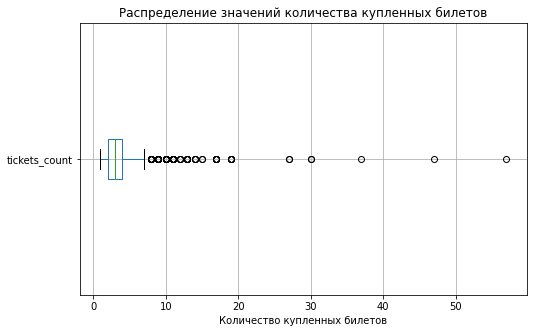

In [24]:
plt.figure(figsize=(8,5))

df.boxplot(column='tickets_count', vert=False)

plt.title('Распределение значений количества купленных билетов')
plt.xlabel('Количество купленных билетов')

plt.show()

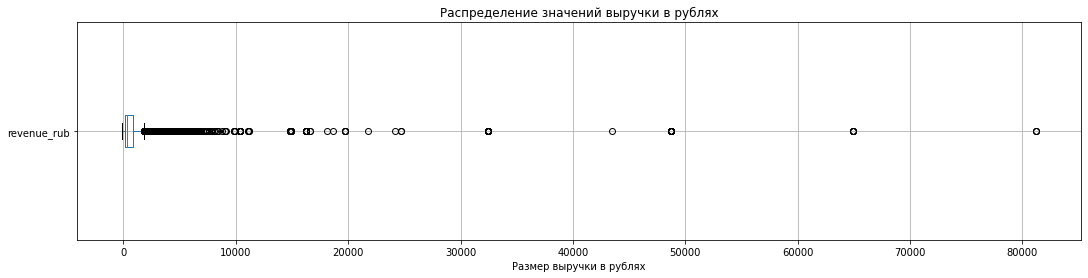

In [25]:
plt.figure(figsize=(18,4))

df.boxplot(column='revenue_rub', vert=False)

plt.title('Распределение значений выручки в рублях')
plt.xlabel('Размер выручки в рублях')

plt.show()

In [26]:
print(f"\nДиапазон выручки: {df['revenue_rub'].min()} - {df['revenue_rub'].max()}")



Диапазон выручки: -90.76 - 81174.54


В значениях выручки присутствуют отрицательные значения. Это могут быть возвраты или ошибки в данных. Такие данные могут мешать анализу. Удалим значения меньше нуля

In [27]:
original_rows = len(df)

df['revenue_rub'] = df['revenue_rub'].where(df['revenue_rub'] >= 0)
df = df.dropna(subset=['revenue_rub'])

new_rows_revenue = len(df)

deleted_rows_revenue = original_rows - new_rows_revenue

print(f"\nДиапазон выручки: {df['revenue_rub'].min()} - {df['revenue_rub'].max()}")

print(f'Количество удаленных строк после удаления отрицательных значений:')
print(deleted_rows_revenue)


Диапазон выручки: 0.0 - 81174.54
Количество удаленных строк после удаления отрицательных значений:
381


In [28]:
percentile_99 = df['revenue_rub'].quantile(0.99)

df = df[df['revenue_rub'] <= percentile_99]

new_rows = len(df)

deleted_rows_perc = new_rows_revenue - new_rows

deleted_rows = original_rows - new_rows

deleted_rows_ratio = round((deleted_rows/original_rows) * 100,2)

print(f'Количество удаленных строк после фильтрации по персентилю:{deleted_rows_perc}')

print(f'Общее количество удаленных строк:{deleted_rows}')

print(f"Относительное количество удаленных строк:{deleted_rows_ratio}%")

Количество удаленных строк после фильтрации по персентилю:2825
Общее количество удаленных строк:3206
Относительное количество удаленных строк:1.1%


# 2.2.4 Снижаем размерность

In [29]:
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='integer')

1. Во время обработки данных был создан новый столбец revenue_rub, в котором выручка в тенге была конвертирована в рубли в соответствии с курсом 2024. 
    

2. Столбцы order_id и event_id были приведены к типу object. Days_since_prev был переведен в Int64, а категориальные данные device_type_canonical и event_type_main были переведены в тип category.


3. В столбцах с номинальными данными была проведена проверка на дубликаты, а также проверка на дубликаты в связке user_id и order_id. Никаких дубликатов выявлено не было. Была проведена проверка на наличие дубликатов заказов с разными order_id, но одинаковыми выручками и временем заказа, дубликаты были найдены и впоследствии было удалено 0,018% строк. В остальных данных дубликаты выявлены не были.
    
    
4. Был проведен анализ, есть ли в данных пропуски в значении days_since_prev не у первых заказов. Было выявлено, что все пропуски обуславливаются тем, что пользователи совершали лишь один заказ. Был изучен столбец days_since_prev, там было найден 21984 пустых строк и 71% нулевых строк. Для столбцов revenue_rub и tickets_count была сделана диаграмма размаха. В обоих столбцах наблюдается большое количество выбросов. В столбце tickets_count максимальный выброс выходит за 50. Значение большое, но реальное. Так как нам требуется провести анализ возвращающихся клиентов, то значения с большим количеством покупок не стоит отметать. Столбец revenue_rub был отсортирован по 99-у персентилю(2825) и были удалены отрицательные значения(381). Сортировка по 99-му персентилю произошла, так как много аномальных значений находится за пределами 40000 в то время, как основное количество значений находится намного ниже 10000. В итоге данные уменьшились на 3206 строк(1,1%).

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [30]:
user_profile = (df
          # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
          .sort_values(by='order_ts')
          # Затем группируем по номеру пользователя и агрегируем данные:
          .groupby('user_id')
          .agg(
              # Находим первую и последнюю даты заказа:
              first_order_date=('order_dt','min'),
              last_order_date=('order_dt','max'),
              # Находим устройства, регион, название билетного партнера и жанр мероприятия первого заказа:
              device_first=('device_type_canonical','first'),
              region_first=('region_name','first'),
              first_service=('service_name','first'),
              first_genre=('event_type_main','first'),
              # Подсчитваем количество заказов:
              total_orders=('order_id','nunique'),
              # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
              avg_revenue=('revenue_rub','mean'),
              avg_tickets=('tickets_count','mean'),
              # Считаем среднее количество дней между покупками:
              avg_time=('days_since_prev','mean')
          )
          # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
          .assign(
              is_two = lambda x: x['total_orders'] >= 2,
              is_five = lambda x: x['total_orders'] >= 5
          )
          .reset_index()
  )

user_profile.head()

,user_id,first_order_date,last_order_date,device_first,region_first,first_service,first_genre,total_orders,avg_revenue,avg_tickets,avg_time,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,74.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,50.5,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,15.0,True,False


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [31]:
total_users = user_profile['user_id'].count()
total_avg_revenue = round((user_profile['avg_revenue'].mean()), 2)
user_profile['is_two'] = user_profile['is_two'].astype('int8')
user_profile['is_five'] = user_profile['is_five'].astype('int8')
two_orders_ratio = round((user_profile['is_two'].sum()/len(user_profile)), 3)
five_orders_ratio = round((user_profile['is_five'].sum()/len(user_profile)), 3)

print(f'Общее число пользователей в выборке: {total_users}')
print(f'Средняя выручка с одного заказа: {total_avg_revenue}')
print(f'Доля пользователей, совершивших 2 и более заказов: {two_orders_ratio}')
print(f'Доля пользователей, совершивших 5 и более заказов: {five_orders_ratio}')

Общее число пользователей в выборке: 21838
Средняя выручка с одного заказа: 545.03
Доля пользователей, совершивших 2 и более заказов: 0.617
Доля пользователей, совершивших 5 и более заказов: 0.29


In [32]:
columns_to_check = ['total_orders', 'avg_tickets', 'avg_time']
stats = user_profile[columns_to_check].isna().sum()/len(user_profile)
print(stats)

total_orders    0.000000
avg_tickets     0.000000
avg_time        0.381583
dtype: float64


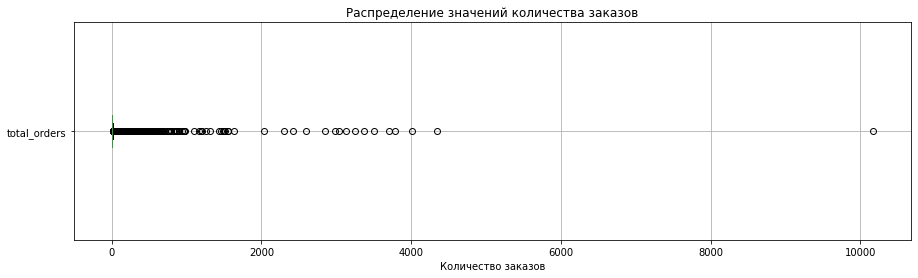

In [33]:
plt.figure(figsize=(15,4))

user_profile.boxplot(column='total_orders', vert=False)

plt.title('Распределение значений количества заказов')
plt.xlabel('Количество заказов')

plt.show()

Во время изучения статистических показателей количества заказов были выявлены аномальные значения. Какие-то значения превышают 10 000 заказов, что во многом отличается от среднего числа, не превышающего 10 заказов. Эти выбросы могут помешать адекватно оценить данные и провести дальнейший анализ. Скорее всего такие выбросы являются ошибкой данных, чтобы исключить неверный анализ, было принято решение отфильтровать данные по 99-у персентилю. Во время фильтрации удалено 216 строк

In [34]:
original_rows_profile = len(user_profile)

percentile_99 = user_profile['total_orders'].quantile(0.99)

user_profile = user_profile[user_profile['total_orders'] <= percentile_99]

new_rows_profile = len(user_profile)

deleted_rows_profile = original_rows_profile - new_rows_profile

deleted_rows_ratio = round((deleted_rows_profile/original_rows_profile) * 100, 2)

print(f'Количество удаленных строк:{deleted_rows_profile}')
print(f'Относительная доля удаленных строк:{deleted_rows_ratio}')

Количество удаленных строк:216
Относительная доля удаленных строк:0.99


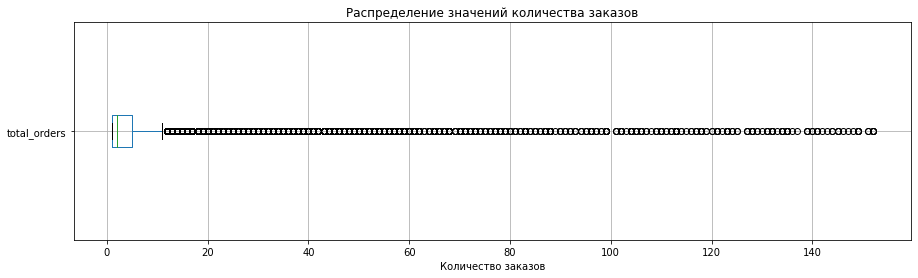

In [35]:
plt.figure(figsize=(15,4))

user_profile.boxplot(column='total_orders', vert=False)

plt.title('Распределение значений количества заказов')
plt.xlabel('Количество заказов')

plt.show()

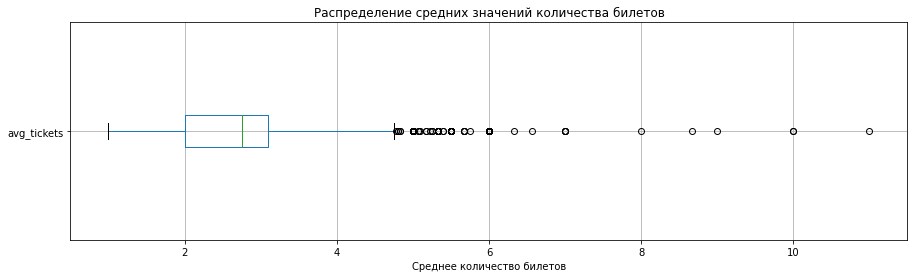

In [36]:
plt.figure(figsize=(15,4))

user_profile.boxplot(column='avg_tickets', vert=False)

plt.title('Распределение средних значений количества билетов')
plt.xlabel('Среднее количество билетов')

plt.show()

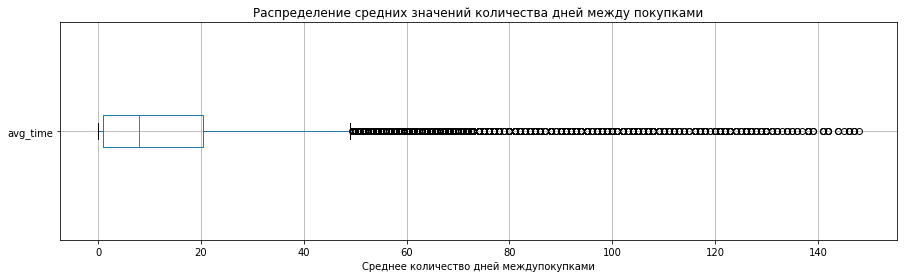

In [37]:
plt.figure(figsize=(15,4))

user_profile.boxplot(column='avg_time', vert=False)

plt.title('Распределение средних значений количества дней между покупками')
plt.xlabel('Среднее количество дней междупокупками')

plt.show()

In [38]:
total_users = user_profile['user_id'].count()
total_avg_revenue = round((user_profile['avg_revenue'].mean()), 2)
user_profile['is_two'] = user_profile['is_two'].astype('int8')
user_profile['is_five'] = user_profile['is_five'].astype('int8')
two_orders_ratio = round((user_profile['is_two'].sum()/len(user_profile)), 3)
five_orders_ratio = round((user_profile['is_five'].sum()/len(user_profile)), 3)

print(f'Общее число пользователей в выборке после фильтрации: {total_users}')
print(f'Средняя выручка с одного заказа после фильтрации: {total_avg_revenue}')
print(f'Доля пользователей, совершивших 2 и более заказов после фильтрации: {two_orders_ratio}')
print(f'Доля пользователей, совершивших 5 и более заказов после фильтрации: {five_orders_ratio}')

Общее число пользователей в выборке после фильтрации: 21622
Средняя выручка с одного заказа после фильтрации: 545.34
Доля пользователей, совершивших 2 и более заказов после фильтрации: 0.613
Доля пользователей, совершивших 5 и более заказов после фильтрации: 0.283


In [39]:
user_profile.describe(percentiles=[.25,.35,.45,.5,.75,.8,.9])

,total_orders,avg_revenue,avg_tickets,avg_time,is_two,is_five
count,21622.000000,21622.000000,21622.000000,13289.000000,21622.000000,21622.000000
mean,6.496624,545.342996,2.744256,15.834288,0.613218,0.282860
std,14.310784,433.545007,0.917491,22.324965,0.487024,0.450399
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,211.057500,2.000000,1.000000,0.000000,0.000000
35%,1.000000,312.524000,2.375000,3.742857,0.000000,0.000000
45%,2.000000,414.120000,2.625000,6.473684,1.000000,0.000000
50%,2.000000,464.656597,2.750000,8.000000,1.000000,0.000000
75%,5.000000,768.573333,3.100000,20.333333,1.000000,1.000000
80%,7.000000,857.390000,3.400000,25.250000,1.000000,1.000000


Во время изучения статистических показателей профиля пользователя были выявлены аномальные значения в столбце total_orders, поэтому столбец был отфильтрован по 99-у персентилю, были удалены 216 строк(0,99%). После фильтрации средняя выручка осталась такой же, доли людей с 2 и 5 заказами снизилась лишь на сотые.
В столбце avg_tickets были выявлены выбросы, но они допустимы в данных значениях, так как показатели находятся в пределах разумного и лояльные покупатели вполне могут иметь такие показатели. В столбце avg_time также были обнаружены выбросы, но они указывают на неактивность пользователя, что важно для анализа, поэтому эти данные остались нетронутыми. Но в стобце avg_time наблюдается 38% пропусков.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---

In [40]:
#Функция, вычисляющая общее количество пользователей
#и долю пользователей, соверших 2+ заказов в сегменте
def stats_segments(df, column):
    grouped = df.groupby(column).size().sort_values(ascending=False)
    two_ratio = df.groupby(column)['is_two'].mean().sort_values(ascending=False)
    return grouped, two_ratio

**Расчеты по типу первого мероприятия**

In [41]:
result_event, ratio_event = stats_segments(user_profile, 'first_genre')

print(f'Общее количество пользователей по типу их первого мероприятия:')
print(result_event)
print(f'Доля пользователей, совершивших два и более заказов, по типу их первого мероприятия:')
print(ratio_event)

Общее количество пользователей по типу их первого мероприятия:
first_genre
концерты    9564
другое      5401
театр       4245
стендап     1110
спорт        794
выставки     413
ёлки          95
dtype: int64
Доля пользователей, совершивших два и более заказов, по типу их первого мероприятия:
first_genre
выставки    0.641646
театр       0.634393
концерты    0.618151
стендап     0.609009
другое      0.595630
спорт       0.557935
ёлки        0.557895
Name: is_two, dtype: float64


**Расчеты по типу устройства, с которого совершена первая покупка**

In [42]:
result_device, ratio_device = stats_segments(user_profile, 'device_first')

print(f'Общее количество пользователей по типу устройства, с которого была совершена первая покупка:')
print(result_device)
print(f'Доля пользователей, совершивших два и более заказов, по типу устройства, с которого совершена первая покупка:')
print(ratio_device)

Общее количество пользователей по типу устройства, с которого была совершена первая покупка:
device_first
mobile     17906
desktop     3716
dtype: int64
Доля пользователей, совершивших два и более заказов, по типу устройства, с которого совершена первая покупка:
device_first
desktop    0.638321
mobile     0.608008
Name: is_two, dtype: float64


**Расчеты по региону первого мероприятия**

In [43]:
result_region, ratio_region = stats_segments(user_profile, 'region_first')

print(f'Общее количество пользователей по региону первого мероприятия:')
print(result_region)
print(f'Доля пользователей, совершивших два и более заказов, по региону первого мероприятия:')
print(ratio_region)

Общее количество пользователей по региону первого мероприятия:
region_first
Каменевский регион          7086
Североярская область        3768
Широковская область         1223
Озернинский край             675
Малиновоярский округ         526
                            ... 
Залесский край                 2
Тихогорская область            2
Верхозёрский край              1
Сосноводолинская область       1
Яснопольский округ             1
Length: 81, dtype: int64
Доля пользователей, совершивших два и более заказов, по региону первого мероприятия:
region_first
Верхозёрский край           1.000000
Озернопольская область      0.896552
Радужнопольский край        0.791667
Лесостепной край            0.716667
Горноземский регион         0.689655
                              ...   
Теплоозёрский округ         0.333333
Крутоводский регион         0.333333
Островогорский округ        0.200000
Сосноводолинская область    0.000000
Яснопольский округ          0.000000
Name: is_two, Length: 81, dtype

**Расчеты по билетному оператору, продавшему билеты на первый заказ**

In [44]:
result_service, ratio_service = stats_segments(user_profile, 'first_service')

print(f'Общее количество пользователей по билетному сервису, продавшему билеты на первый заказ:')
print(result_service)
print(f'Доля пользователей, совершивших два и более заказов, по билетному сервису, продавшему билеты на первый заказ:')
print(ratio_service)

Общее количество пользователей по билетному сервису, продавшему билеты на первый заказ:
first_service
Билеты без проблем        5167
Мой билет                 2970
Лови билет!               2812
Билеты в руки             2557
Облачко                   2177
Весь в билетах            1286
Лучшие билеты             1182
Прачечная                  583
Край билетов               454
Дом культуры               356
Яблоко                     318
Тебе билет!                308
Городской дом культуры     215
Мир касс                   210
За билетом!                201
Быстробилет                162
Show_ticket                157
Выступления.ру              95
Восьмёрка                   85
Быстрый кассир              61
Crazy ticket!               45
Росбилет                    40
Радио ticket                36
Реестр                      33
Телебилет                   27
Цвет и билет                23
Шоу начинается!             19
КарандашРУ                  15
Кино билет                   9

**Графики распределения заказов по типу их первого мероприятия**

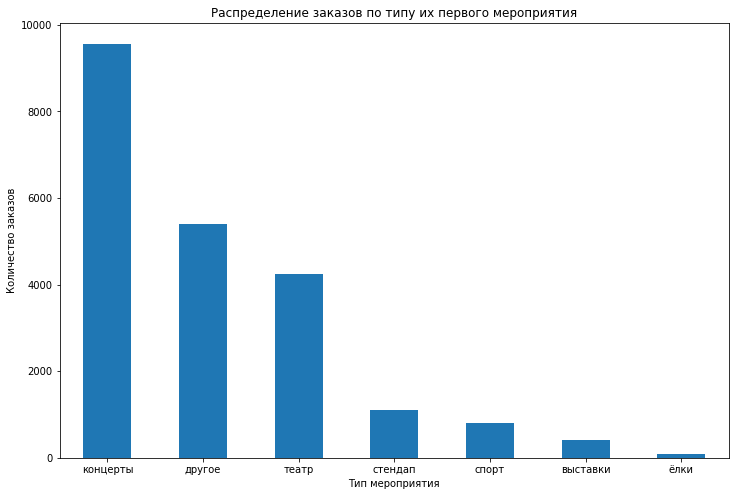

In [45]:
plt.figure(figsize=(12,8))
result_event.sort_values(ascending=False).plot(
                kind='bar',
                rot=0,
                legend=False,
                title=f'Распределение заказов по типу их первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество заказов')

plt.show()

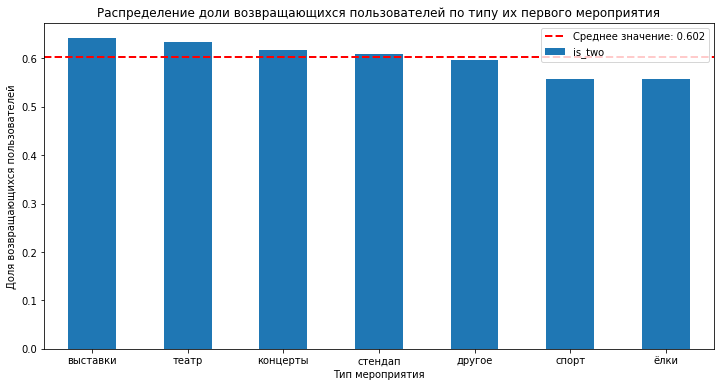

In [46]:
plt.figure(figsize=(12,6))
ratio_event.sort_values(ascending=False).plot(
                kind='bar',
                rot=0,
                legend=False,
                title=f'Распределение доли возвращающихся пользователей по типу их первого мероприятия')

mean_value = ratio_event.mean()  # среднее значение по всем типам
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее значение: {mean_value:.3f}')

plt.xlabel('Тип мероприятия')
plt.ylabel('Доля возвращающихся пользователей')

plt.legend()
plt.show()

**Круговая диаграммы распределения заказов по типу устройства, с которого был совершен первый заказ**

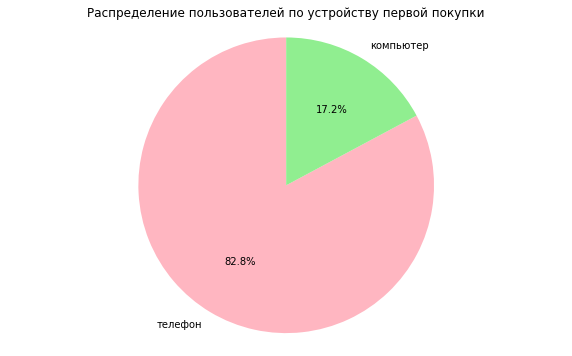

In [47]:
plt.figure(figsize=(10,6))
plt.pie(result_device.values, 
        labels=['телефон', 'компьютер'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightpink', 'lightgreen'])
plt.title('Распределение пользователей по устройству первой покупки')
plt.axis('equal')
plt.show()

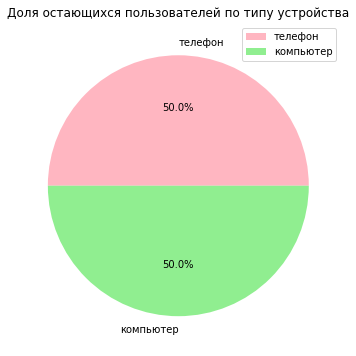

In [48]:
plt.figure(figsize=(10,6))

ratio_device.value_counts().plot(
                                kind='pie',
                                labels=['телефон', 'компьютер'],
                                rot=0,
                                autopct='%1.1f%%',
                                legend=True,
                                title=f'Доля остающихся пользователей по типу устройства',
                                colors=['lightpink', 'lightgreen'])
plt.xlabel('')
plt.ylabel('')

plt.grid()

plt.show()

**Графики распределения заказов по их первому региону**

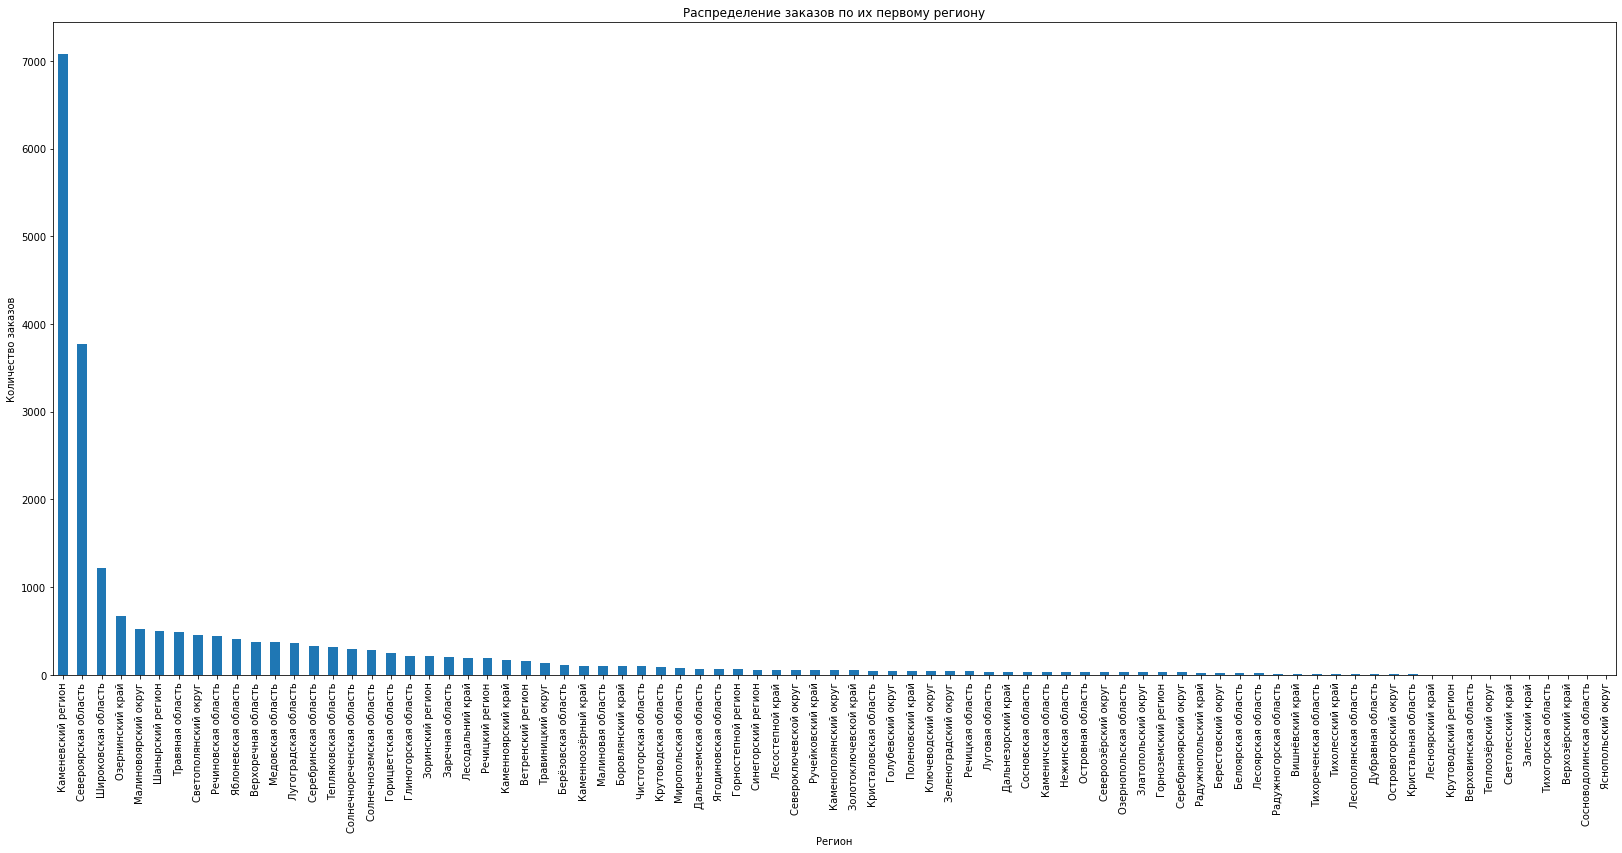

In [49]:
plt.figure(figsize=(28,12))
result_region.sort_values(ascending=False).plot(
                kind='bar',
                rot=90,
                legend=False,
                title=f'Распределение заказов по их первому региону')
plt.xlabel('Регион')
plt.ylabel('Количество заказов')

plt.show()

In [50]:
ratio_region_head = ratio_region.head(10)

ratio_deleted_region = round((len(ratio_region_head)/len(ratio_region)) * 100, 3)

print(f'Топ-10 регионов по возвращению клиентов:{ratio_region_head}')
print(f'Доля выбранных 10 регионов от общего числа: {ratio_deleted_region}%')

Топ-10 регионов по возвращению клиентов:region_first
Верхозёрский край         1.000000
Озернопольская область    0.896552
Радужнопольский край      0.791667
Лесостепной край          0.716667
Горноземский регион       0.689655
Шанырский регион          0.673307
Горицветская область      0.668016
Ягодиновская область      0.666667
Верховинская область      0.666667
Тихолесский край          0.666667
Name: is_two, dtype: float64
Доля выбранных 10 регионов от общего числа: 12.346%


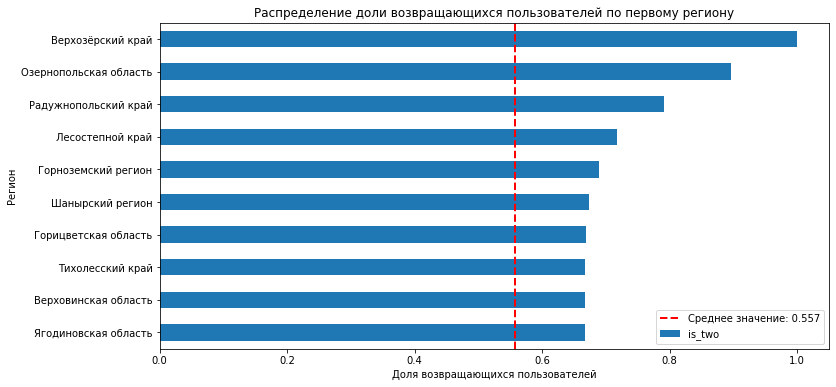

In [51]:
plt.figure(figsize=(12,6))
ratio_region_head.sort_values().plot(
                kind='barh',
                rot=0,
                legend=False,
                title=f'Распределение доли возвращающихся пользователей по первому региону')

mean_value = ratio_region.mean()  # среднее значение по всем типам
plt.axvline(x=mean_value, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее значение: {mean_value:.3f}')

plt.ylabel('Регион')
plt.xlabel('Доля возвращающихся пользователей')

plt.legend()
plt.show()

**Графики распределения заказов по сервису, с которого был сделан первый заказ**

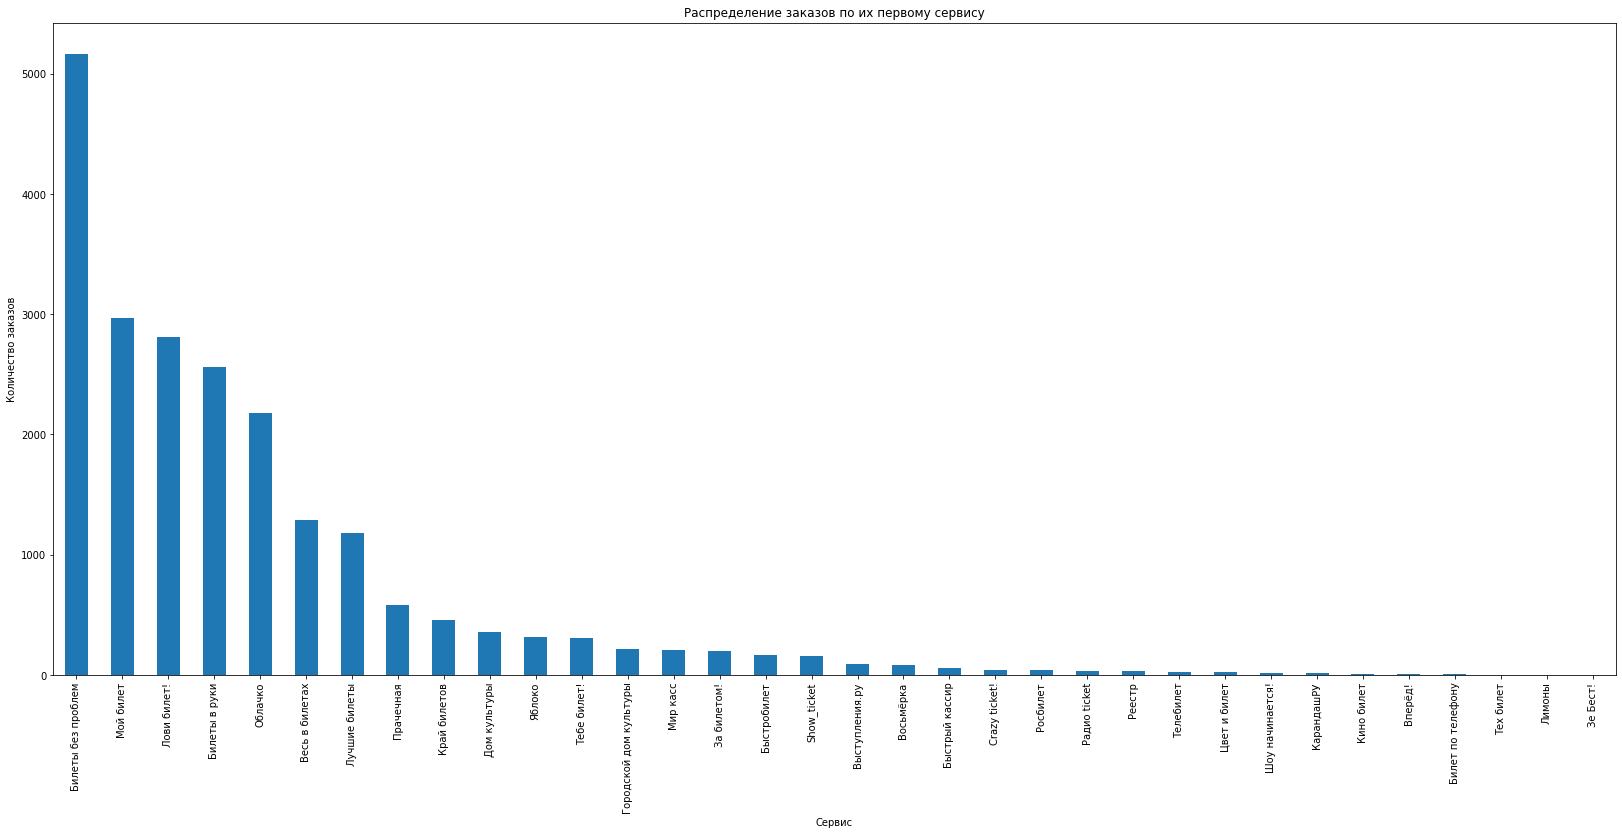

In [52]:
plt.figure(figsize=(28,12))
result_service.sort_values(ascending=False).plot(
                kind='bar',
                rot=90,
                legend=False,
                title=f'Распределение заказов по их первому сервису')
plt.xlabel('Сервис')
plt.ylabel('Количество заказов')

plt.show()

In [53]:
ratio_service_head = ratio_service.head(10)

ratio_deleted_service = round((len(ratio_service_head)/len(ratio_service)) * 100, 3)

print(f'Топ-10 сервисов по возвращению клиентов:{ratio_service_head}')
print(f'Доля выбранных 10 сервисов от общего числа: {ratio_deleted_service}%')

Топ-10 сервисов по возвращению клиентов:first_service
Зе Бест!             1.000000
Быстрый кассир       0.852459
Билет по телефону    0.833333
Реестр               0.818182
Crazy ticket!        0.688889
Восьмёрка            0.682353
Цвет и билет         0.652174
Край билетов         0.651982
Росбилет             0.650000
Show_ticket          0.649682
Name: is_two, dtype: float64
Доля выбранных 10 сервисов от общего числа: 29.412%


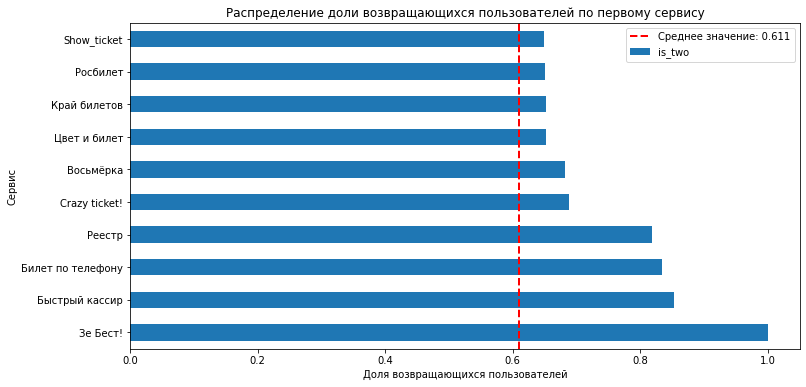

In [54]:
plt.figure(figsize=(12,6))
ratio_service_head.sort_values(ascending=False).plot(
                kind='barh',
                rot=0,
                legend=False,
                title=f'Распределение доли возвращающихся пользователей по первому сервису')

mean_value = ratio_service.mean()  # среднее значение по всем типам
plt.axvline(x=mean_value, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее значение: {mean_value:.3f}')

plt.ylabel('Сервис')
plt.xlabel('Доля возвращающихся пользователей')

plt.legend()
plt.show()

Пользователи распределены неравномерно. 
- В группировке по типу первого мероприятия заметно, что большинство пользователей впервые купили билет на концерт. Скорее всего это происходит из-за того, что концерты сами по себе являются наиболее популярными типами мероприятий среди средневозрастной группы пользователей.
- В группировке по типу устройства можно видеть, что более 80% пользователей впервые купили билет с мобильного устройства. Это ожидаемо, ведь телефон всегда под рукой и всегда есть возможность купить билет.
- В группировке по региону заметно, что в Каменевском регионе пользователи чаще всего совершали свой первый заказ, показатели на 3351 человека больше в сравнении со вторым регионом - Североярским. 
- В группировке по сервису заметно, что в сервисе "Билеты без проблем" было совершено больше всего первых заказов(5212), на 2228 пользователей больше чем во втром показателе.

- Какие сегменты пользователей чаще возвращаются на Яндекс Афишу? 

Чаще всего возвращаются пользователи, чьих первым типом мероприятия были выставки. Можно предположить, что это происходит из-за того, что выставки являются достаточно малопопулярным типом мероприятий, поэтому их посещают люди, которые делают это не в первый раз(ранее не через сервис) либо сильно любят искусство, поэтому точно возвращаются. Тип устройства не влияет на возвращаемость пользователя. Чаще всего возвращающиеся пользователи делают заказ в Верхозёрском крае. Возможно, в этом регионе проходит больше всего мероприятий или же там находится больше всего музеев/выставок. Возвращающиеся пользователи чаще всего делают первый заказ на сайте "Зе Бест!", скорее всего данный сайт предлагает больше разнообразия или более выгодные предложения.

- Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке? 
Успешной "точкой входа" является регион(скорее всего из-за разнообразия мероприятий в нем) и сервис(из-за большого количества предложений и возможно выгодных цен).

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

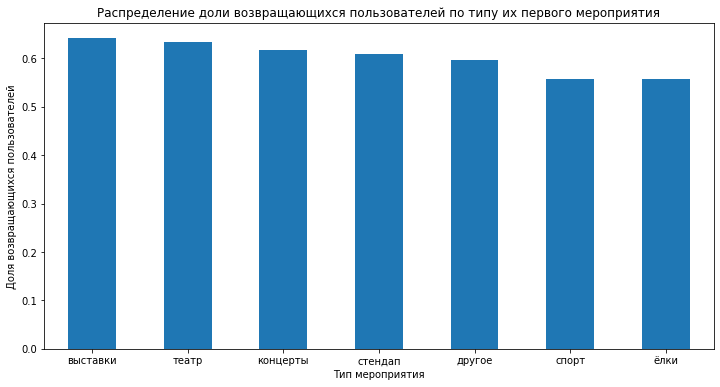

In [55]:
plt.figure(figsize=(12,6))
ratio_event.sort_values(ascending=False).plot(
                kind='bar',
                rot=0,
                legend=False,
                title=f'Распределение доли возвращающихся пользователей по типу их первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля возвращающихся пользователей')

plt.show()

Гипотеза 1 не подтверждается. Тип первого мероприятия минимально влияет на возвращение пользователей. Все показатели находятся на уровне 60%.

In [56]:
region_stats = user_profile.groupby('region_first').agg({
    'user_id': 'count',
    'is_two': 'sum'}).reset_index()

region_stats.columns = ['region', 'total_users', 'repeat_customers']

region_stats['repeat_rate'] = (region_stats['repeat_customers'] / region_stats['total_users'] * 100).round(2)

min_users = 10
region_stats = region_stats[region_stats['total_users'] >= min_users]

region_stats = region_stats.sort_values('repeat_rate', ascending=False)

print(region_stats[['region', 'total_users', 'repeat_customers', 'repeat_rate']].to_string(index=False))

                   region  total_users  repeat_customers  repeat_rate
   Озернопольская область           29              26.0        89.66
     Радужнопольский край           24              19.0        79.17
         Лесостепной край           60              43.0        71.67
      Горноземский регион           29              20.0        68.97
         Шанырский регион          502             338.0        67.33
     Горицветская область          247             165.0        66.80
     Ягодиновская область           63              42.0        66.67
      Берёзовская область          111              73.0        65.77
     Светополянский округ          457             300.0        65.65
          Речицкий регион          188             123.0        65.43
       Белоярская область           20              13.0        65.00
         Заречная область          203             131.0        64.53
      Широковская область         1223             788.0        64.43
     Североярская об

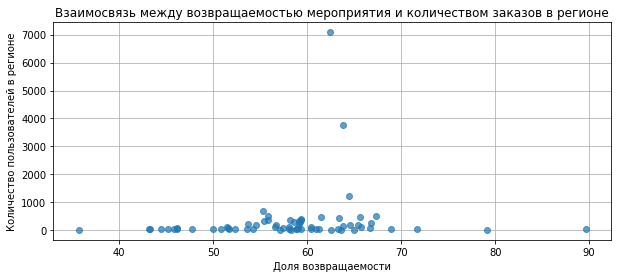

In [57]:
plt.figure(figsize=(10, 4))

# Строим линейный график
plt.plot(region_stats['repeat_rate'],
         region_stats['total_users'],
         marker='o', # Задаём стиль маркера
         linestyle='', # Делаем линии между точками невидимыми
         alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между возвращаемостью мероприятия и количеством заказов в регионе')
plt.xlabel('Доля возвращаемости')
plt.ylabel('Количество пользователей в регионе')
plt.grid()

# Отображаем график
plt.show()

Гипотеза не подтверждается. В регионах с самым большим посещением, статистическим показателям которых мы можем доверять, доля повторное посещаемости остается примерно на одном уровне.

После анализа сегментов можно судить о том, ~~~~что среди изученных данных больше всего на возвращаемость клиента влияет регион(скорее всего потому, что там проходит больше всего мероприятий) и сервис(который предлагает больше всего услуг). Тип устройства, с которого осуществляется первая покупка, практически не влияет на возвращаемость клиента. В типах мероприятий чаще всего возвращаются пользователи, которые впервые покупают билеты на выставки. Скорее всего это связано с тем, что туда изнчально идут люди, любящие искусство, и выставки проходят довольно часто.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


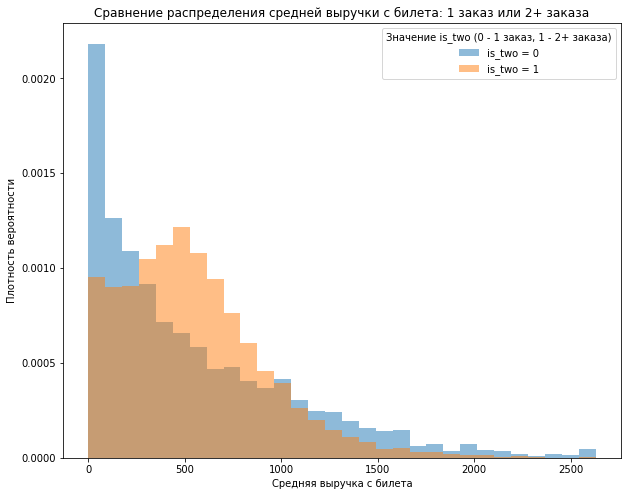

In [58]:
plt.figure(figsize=(10, 8))

for i in user_profile['is_two'].unique():
    user_profile.loc[user_profile['is_two'] == i, 'avg_revenue'].plot(
        kind='hist',
        density=True,
        bins=30,
        alpha=0.5,
        label=f'is_two = {i}',
        legend=True
    )

plt.title('Сравнение распределения средней выручки с билета: 1 заказ или 2+ заказа')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение is_two (0 - 1 заказ, 1 - 2+ заказа)')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

- В каких диапазонах средней выручки концентрируются пользователи из каждой группы? 
У пользователей с одним заказом средняя выручка концентрируется в значении нуля и дальше идет на спад. Это говорит о том, что мало заинтересованный пользователь не станет покупать дорогие для него билеты. Скорее всего он не совершает дополнительных покупок, потому что изначально не заинтересован в сервисе. У пользователей с двумя и более заказов средняя выручка в районе 500 рублей. Это означает, что именно с такой средней ценой пользователь будет возвращаться на сервис и брать больше билетов. Когда средняя выручка пересекает значение 1000 показатели пользователей с 2 и более покупками сравниваются с показателями пользователей лишь с одной покупкой. Это говорит о том, что со средней ценой за билет за 1000 пользователь вряд ли будет готов возвращаться.

- Есть ли различия между группами? 
У пользователей со средней выручкой за заказ больше вероятностей остаться на платформе. Но стоит также обратить внимание, что когда средняя выручка становится больше 1000рублей, показатели групп сравниваются.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [59]:
def define_group(row):
    if row['is_five'] == 1:
        return '5 и более заказов'
    elif row['is_two'] == 1 and row['is_five'] == 0:
        return '2-4 заказа'
    else:
        return '1 заказ (исключаем из анализа)'

user_profile['order_group'] = user_profile.apply(define_group, axis=1)

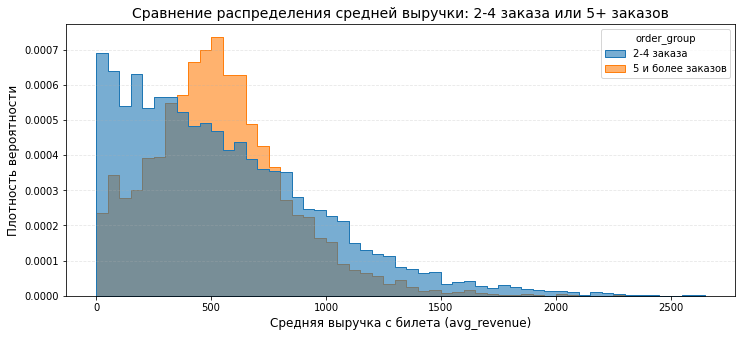

In [60]:
user_profile_filtered = user_profile[user_profile['is_two'] == 1].copy()

user_profile_filtered.loc[:, 'order_group'] = user_profile_filtered['is_five'].map({
    0: '2-4 заказа',
    1: '5 и более заказов'
})

plt.figure(figsize=(12, 5))

# Используем seaborn с общими бинами
sns.histplot(
    data=user_profile_filtered,
    x='avg_revenue',
    hue='order_group',
    bins=range(int(user_profile_filtered['avg_revenue'].min()), 
               int(user_profile_filtered['avg_revenue'].max()) + 50, 50),
    stat='density',
    common_bins=True,
    alpha=0.6,
    element='step'
)

plt.title('Сравнение распределения средней выручки: 2-4 заказа или 5+ заказов', fontsize=14)
plt.xlabel('Средняя выручка с билета (avg_revenue)', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

По графику видно, что больше всего вероятность пользователя совершить 5 и более заказов происходит при выручке примерно в 500-700 рублей, после этих значений чем выше выручка, тем ниже вероятность. Вероятность пользователя купить 2-4 билетов падает при повышении стоимости.

Анализ показал, что наибольшая возвращаемость происходит у пользователя, который покупает билеты в районе 500-700 рублей. При слишком низкой выручке пользователь достаточно редко возвращается. Скорее всего это связано с тем, что уровень низкостоящих мероприятий чаще всего бывает нижесреднего, поэтому пользователь остается с плохими мнениями. Также стоит отметить, что после 700 рублей пользователь начинает реже покупать повторные билеты, скорее всего это связано с тем, что пользователь остается недовольным ценой и старается найти менее затратные сервисы. В будущем стоит иметь в виду, что цены стоит держать в средних пределах(500-700 рублей).

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [61]:
bins = [1, 2, 3, 5, float('inf')]
labels = ['1 - 2 билетов', '2 - 3 билетов', '3 - 5 билетов', '5 и более билетов']

user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets'], 
    bins=bins, 
    labels=labels, 
    right=False, 
    include_lowest=True
)

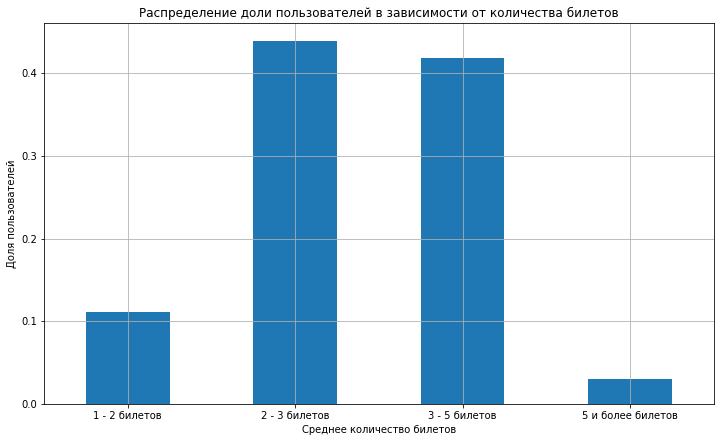

In [62]:
plt.figure(figsize=(12, 7))

user_profile['tickets_segment'].value_counts(normalize=True).sort_index().plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Распределение доли пользователей в зависимости от количества билетов'
)

plt.xlabel('Среднее количество билетов')
plt.ylabel('Доля пользователей')
plt.grid()

plt.show()

Большинство пользователей в среднем приобретают от 2 до 3 билетов. Скорее всего потому, что на мероприятия люди чаще всего ходят со второй половинкой или семьей. Поэтому у большей части людей среднее количество билетов в заказе выше двух, но не достигает 5. Меньше всего пользователей покупают 5 и более билетов, так как собрать такую большую компанию достаточно сложно, в эту категорию скорее всего попадают многодетные семьи или большие группы друзей.

In [63]:
segment_stats = user_profile.groupby('tickets_segment', observed=True).agg(
    total_users=('user_id', 'count'),
    repeat_users=('is_two', 'sum'),  
    repeat_rate=('is_two', 'mean')
).reset_index()

segment_stats['users_percent'] = (segment_stats['total_users'] / segment_stats['total_users'].sum() * 100).round(1)
segment_stats['repeat_rate_percent'] = (segment_stats['repeat_rate'] * 100).round(1)

segment_stats['tickets_segment'] = pd.Categorical(segment_stats['tickets_segment'], ordered=True)
segment_stats = segment_stats.sort_values('tickets_segment')

print("Статистика по сегментам:")
print(segment_stats[['tickets_segment', 'total_users', 'users_percent', 'repeat_users', 'repeat_rate_percent']])
print("\n")

Статистика по сегментам:
     tickets_segment  total_users  users_percent  repeat_users  \
0      1 - 2 билетов         2410           11.1        1235.0   
1      2 - 3 билетов         9487           43.9        6979.0   
2      3 - 5 билетов         9064           41.9        4921.0   
3  5 и более билетов          661            3.1         124.0   

   repeat_rate_percent  
0                 51.2  
1                 73.6  
2                 54.3  
3                 18.8  




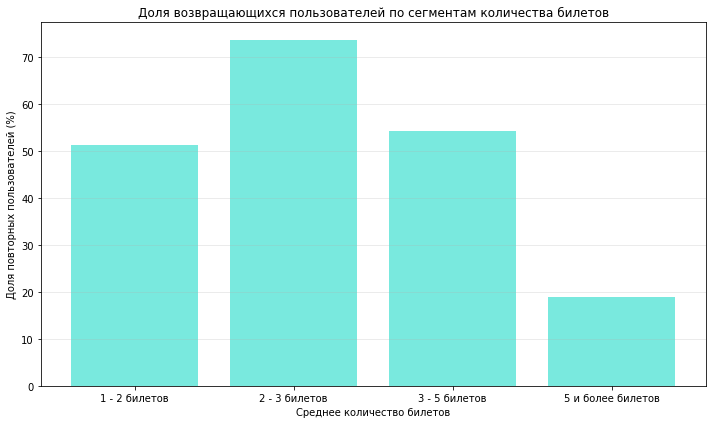

In [64]:
plt.figure(figsize=(10, 6))

plt.bar(segment_stats['tickets_segment'], 
        segment_stats['repeat_rate_percent'],
        color='turquoise',
        alpha=0.7)

plt.xlabel('Среднее количество билетов')
plt.ylabel('Доля повторных пользователей (%)')
plt.title('Доля возвращающихся пользователей по сегментам количества билетов')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- Как распределены пользователи по сегментам — равномерно или сконцентрировано? 
Пользователи распределены неравномерно. Больше всего пользователей в сегменте "от 2 до 3 билетов" (9487) и меньше всего в сегменте "5 и более билетов" (661). Скорее всего эти данные исходят из распределения не только возвращающихся, но и всех пользователей. Люди в принципе чаще входят в сегмент 2-3 билета, так как чаще всего ходят на мероприятия с другом/второй половинкой или семьей, состоящей из примерно 3-4 людей. Поэтому эти категории и являются самыми возвращающимися. В будущем можно сделать актуальные предложения для многодетных семей/больших компаний друзей, чтобы увеличить возвращаемость людей в сегменте 5+ билетов.

- Есть ли сегменты с аномально высокой или низкой долей повторных покупок? 
Аномально высокой является категория "2-3 билета", но это обуславливается логичными факторами.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [65]:
user_profile['first_order_date'] = user_profile['first_order_date'].astype('datetime64')

user_profile['weekday_name'] = user_profile['first_order_date'].dt.day_name()

In [66]:
weekday_grouped = user_profile.groupby('weekday_name').agg({'user_id':'count', 'is_two':'sum'})

weekday_grouped['is_two_ratio'] = round((weekday_grouped['is_two']/weekday_grouped['user_id']), 3)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_grouped.index = pd.Categorical(weekday_grouped.index, categories=day_order, ordered=True)
weekday_grouped = weekday_grouped.sort_index()

print(weekday_grouped)

           user_id  is_two  is_two_ratio
Monday        2918  1838.0         0.630
Tuesday       3175  1965.0         0.619
Wednesday     3061  1906.0         0.623
Thursday      3112  1850.0         0.594
Friday        3256  1946.0         0.598
Saturday      3323  2086.0         0.628
Sunday        2777  1668.0         0.601


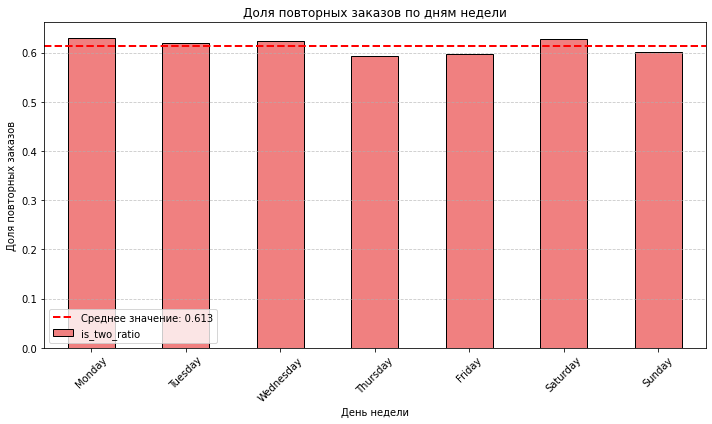

In [67]:
plt.figure(figsize=(10, 6))

weekday_grouped['is_two_ratio'].plot(
    kind='bar',
    rot=45,
    color='lightcoral',
    edgecolor='black',
    title='Доля повторных заказов по дням недели'
)

mean_value = weekday_grouped['is_two_ratio'].mean()  # среднее значение
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее значение: {mean_value:.3f}')

plt.xlabel('День недели')
plt.ylabel('Доля повторных заказов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

Больше всего первых заказов приходится на понедельник, субботу и среду. Скорее всего в понедельник люди с загруженным графиком планируют свою неделю и заранее покупают билеты на мероприятия на неделю или выходные. В среду, когда половина рабочей недели позади пользователи начинают планировать развлекательную программу на пятницу и выходные. В субботу люди, которые оставили планирование на потом или резко осознали, что им нечем заняться, начинают искать билеты на вечер или воскресенье.

Меньше всего покупок происходит в четверг, пятницу и воскресенье. В четверг меньше всего покупок, потому что организованные люди уже скорее всего купили билеты, а спонтанные не покупают ничео заранее. В пятницу мало покупок, потому что если люди заранее не купили никаких билетов, то скорее всего они выберут остаться дома после рабочей недели. В воскресенье мало покупок, потому что неделя уже завершилась и люди пока что не думают о следующей.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [68]:
def define_group_orders(row):
    if row['total_orders'] >= 2 and row['total_orders'] <= 4:
        return '2-4 заказа'
    elif row['total_orders'] >= 5:
        return '5 и более заказов'

user_profile['quantity_orders'] = user_profile.apply(define_group_orders, axis=1)

In [69]:
orders_grouped = user_profile.groupby('quantity_orders').agg({'avg_time':'mean'})

print(orders_grouped)

                    avg_time
quantity_orders             
2-4 заказа         21.067572
5 и более заказов   9.627074


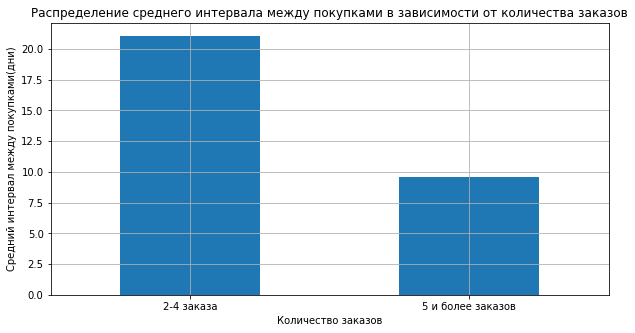

In [70]:
orders_grouped.plot(kind='bar',
               title=f'Распределение среднего интервала между покупками в зависимости от количества заказов',
               legend=False,
               ylabel='Средний интервал между покупками(дни)',
               xlabel='Количество заказов',
               rot=0,
               figsize=(10, 5))
plt.grid()

plt.show()

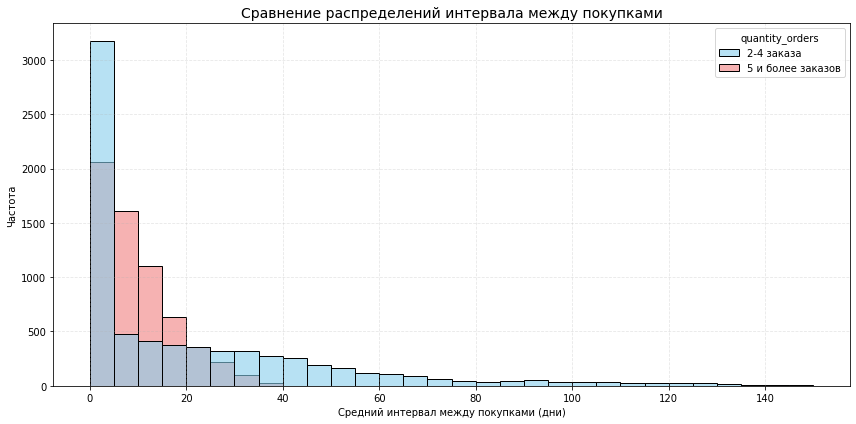

In [71]:
user_profile['is_2_4'] = user_profile['quantity_orders'] == '2-4 заказа'
user_profile['is_5_plus'] = user_profile['quantity_orders'] == '5 и более заказов'

plot_data = user_profile[user_profile['quantity_orders'].isin(['2-4 заказа', '5 и более заказов'])]

bin_width = 5
bins = np.arange(0, plot_data['avg_time'].max() + bin_width, bin_width)

plt.figure(figsize=(12, 6))

# Гистограмма с разделением по группам
sns.histplot(data=plot_data, x='avg_time', hue='quantity_orders', 
             bins=bins, alpha=0.6, palette=['skyblue', 'lightcoral'],
             edgecolor='black', multiple='layer')

plt.title('Сравнение распределений интервала между покупками', fontsize=14)
plt.xlabel('Средний интервал между покупками (дни)')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

График показывает, что у пользователей с 2-4 заказами множество значений ближено к нулю, то есть довольно часто пользователи совершали несколько покупок за короткий срок, но также присутсвуют большие значения, например, 100-140 дней между заказами. У людей с 5+ заказами также средний интервал приближен к нулю, но мы можем заметить, что максимальное значение почти не уходит за 35 дней. Можно сказать, что люди с 5 и более заказами имеют меньший интервал между покупками, но это может подкрепляться тем, что они более часто пользуются сервисом и впринципе совершают покупки. Утверждать, что средний интервал влияет на возвращаемость клиента, нельзя. Скорее наоборот, возвращаемость клиента влияет на средний интервал.

Однако стоит обратить внимание на то, что масимальный средний интервал у пользователя с 5 и более заказами находится в районе одного месяца, поэтому стоит рассмотреть внедрение напоминай пользователю о приблиающихся мероприятиях или других способах интеграций спустя 30 дней.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [72]:
def segment_users(orders):
    if orders == 1:
        return '1 заказ'
    elif 2 <= orders <= 4:
        return '2-4 заказа'
    elif orders >= 5:
        return '5+ заказов'

user_profile['order_segment'] = user_profile['total_orders'].apply(segment_users)

In [73]:
def segment_users(orders):
    if orders == 1:
        return '1 заказ'
    elif 2 <= orders <= 4:
        return '2-4 заказа'
    elif orders >= 5:
        return '5+ заказов'

user_profile['order_segment'] = user_profile['total_orders'].apply(segment_users)

In [74]:
# Сортируем и нумеруем заказы для каждого пользователя
df_sorted = df.sort_values(['user_id', 'order_ts'])
df_sorted['order_rank'] = df_sorted.groupby('user_id').cumcount() + 1

# Извлекаем первый и второй заказ для каждого пользователя
first_orders = df_sorted[df_sorted['order_rank'] == 1][['user_id', 'order_ts']].rename(columns={'order_ts': 'first_order_ts'})
second_orders = df_sorted[df_sorted['order_rank'] == 2][['user_id', 'order_ts']].rename(columns={'order_ts': 'second_order_ts'})

# Объединяем и считаем интервал
order_intervals = first_orders.merge(second_orders, on='user_id', how='left')
order_intervals['first_order_interval'] = (order_intervals['second_order_ts'] - order_intervals['first_order_ts']).dt.days

# Присоединяем к user_profile
user_profile = user_profile.merge(
    order_intervals[['user_id', 'first_order_interval']], 
    on='user_id', 
    how='left'
)
# Декомпозиция дат на категориальные признаки
user_profile['first_order_month'] = user_profile['first_order_date'].dt.month

# фиксированный период наблюдения
end_of_analysis = pd.Timestamp(user_profile['last_order_date'].max())
# observation_window - количество дней, которое прошло с момента первого заказа клиента до конца периода анализа.
user_profile['observation_window'] = (end_of_analysis - user_profile['first_order_date']).dt.days
user_profile['observation_window'] = user_profile['observation_window'].clip(lower=1)

# Нормализуем total_orders на окно наблюдения
user_profile['orders_per_30days'] = (
    user_profile['total_orders'] / user_profile['observation_window'] * 30
)

# 5. Подготовка колонок для phik
columns_to_use = [
    'device_first', 'region_first', 'first_genre', 
    'avg_revenue', 'avg_tickets', 'avg_time', 
    'first_service', 'weekday_name',
    'order_segment', 'first_order_interval',
    'first_order_month', 'observation_window', 'orders_per_30days'
]

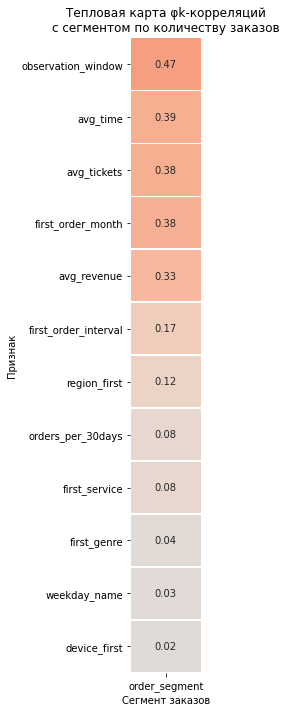


Топ корреляций с order_segment:
                      order_segment
observation_window         0.472794
avg_time                   0.390070
avg_tickets                0.383043
first_order_month          0.382584
avg_revenue                0.325259
first_order_interval       0.173631
region_first               0.123894
orders_per_30days          0.084574
first_service              0.082321
first_genre                0.041037
weekday_name               0.033205
device_first               0.017415


In [75]:
interval_cols = [
    'avg_revenue', 'avg_tickets', 'avg_time',
    'first_order_interval', 'observation_window', 'orders_per_30days'
]

correlation_matrix = user_profile[columns_to_use].phik_matrix(interval_cols=interval_cols)

data_heatmap = (
    correlation_matrix
    .loc[correlation_matrix.index != 'order_segment', ['order_segment']]
    .sort_values(by='order_segment', ascending=False)
)

plt.figure(figsize=(3, 10))
sns.heatmap(
    data_heatmap,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=False,
    vmin=-1, vmax=1
)
plt.title('Тепловая карта φk-корреляций\nс сегментом по количеству заказов')
plt.xlabel('Сегмент заказов')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

print('\nТоп корреляций с order_segment:')
print(data_heatmap)

Наибольшая связь сегментов наблюдается с колонкой observation_window. Эта колонка показывает, сколько дней прошло с первого заказа до момента анализа. Взаимосвязь следует изучить больше в дальнейшем, так как показатель может помочь улучшить возвращаемость пользователей. Если небольшое значение между первым и вторым заказом может помочь привлечь пользователей, то стоит рассмотреть выгодные предложения на второй заказ.
Также подтверждается взаимосвязь в колонках со средним интервалом между заказами, средним количеством билетов в заказе и месяцем первой покупки. Эти показатели стоит учитывать при увеличении возвращаемости клиентов.
Наименьшая связь наблюдается в колонках с первым устройством, с которого был совершен заказ(во время анализа мы уже заметили, что проценты устройств 50/50), день недели первого заказа(было замечено, что распределение находится почти на одном уровне) и типом первого мероприятия(лидируют выставки, но показатели примерно на одном уровне). Эти показатели можно учитывать при повышении возвращаемости, но не уделять сильного внимания.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

# 5.1 Предобработка данных

Во время работы над проектом была проведена предобработка данных. Во время изучения данных было выявлено, что в данных присутствует 290611 ненулевых строк. Пропуски встречаются в столбце days_since_prev, но в данном случае они уместны, так как у пользователя могла быть лишь одна покупка. Столбцы order_id и event_id были переведены в тип object, чтобы они не взаимодейтсвовали с численными данными. С помощью курса тенге за 2024 год было произведено конвертированиецен из тенге в рубли. В столбцах с номинальными данными была проведена проверка на дубликаты, а также проверка на дубликаты в связке user_id и order_id. Никаких дубликатов выявлено не было.
Для столбцов revenue_rub и tickets_count была сделана диаграмма размаха. В обоих столбцах наблюдается большое количество выбросов. Столбец revenue_rub был отсортирован по 99-у персентилю. В итоге данные уменьшились на 2870 строк. 

# 5.2 Анализ данных

Во время анализа было выявлено, что в выборку было отобрано 21854 пользователей. Средняя выручка за заказ составляет 544,4 руб. Во время изучения статистических показателей профиля пользователя были выявлены аномальные значения в столбце total_orders, поэтому столбец был отфильтрован по 99-у персентилю, были удалены 216 строк(0,99%). После фильтрации средняя выручка осталась такой же, доли людей с 2 и 5 заказами снизилась лишь на сотые. В столбце avg_tickets были выявлены выбросы, но они допустимы в данных значениях, так как показатели находятся в пределах разумного и лояльные покупатели вполне могут иметь такие показатели. В столбце avg_time также были обнаружены выбросы, но они указывают на неактивность пользователя, что важно для анализа, поэтому эти данные остались нетронутыми. Но в стобце avg_time наблюдается 38% пропусков.


Чаще всего возвращаются пользователи, чьих первым типом мероприятия были выставки. Можно предположить, что это происходит из-за того, что выставки являются достаточно малопопулярным типом мероприятий, поэтому их посещают люди, которые делают это не в первый раз(ранее не через сервис) либо сильно любят искусство, поэтому точно возвращаются. Тип устройства не влияет на возвращаемость пользователя. Чаще всего возвращающиеся пользователи делают заказ в Верхозёрском крае. Возможно, в этом регионе проходит больше всего мероприятий или же там находится больше всего музеев/выставок. Возвращающиеся пользователи чаще всего делают первый заказ на сайте "Зе Бест!", скорее всего данный сайт предлагает больше разнообразия или более выгодные предложения.

**После анализа сегментов можно судить о том, что среди изученных данных больше всего на возвращаемость клиента влияет регион(скорее всего потому, что там проходит больше всего мероприятий) и сервис(который предлагает больше всего услуг). Тип устройства, с которого осуществляется первая покупка, практически не влияет на возвращаемость клиента.**

**Анализ показал, что наибольшая возвращаемость происходит у пользователя, который покупает билеты в районе 500-700 рублей.** При слишком низкой выручке пользователь достаточно редко возвращается. Скорее всего это связано с тем, что уровень низкостоящих мероприятий чаще всего бывает нижесреднего, поэтому пользователь остается с плохими мнениями. Также стоит отметить, что после 700 рублей пользователь начинает реже покупать повторные билеты, скорее всего это связано с тем, что пользователь остается недовольным ценой и старается найти менее затратные сервисы. В будущем стоит иметь в виду, что цены стоит держать в средних пределах(500-700 рублей).

Больше всего пользователей в сегменте "от 2 до 3 билетов" (9487) и меньше всего в сегменте "5 и более билетов" (661). Скорее всего эти данные исходят из распределения не только возвращающихся, но и всех пользователей. Люди в принципе чаще входят в сегмент 2-3 билета, так как чаще всего ходят на мероприятия с другом/второй половинкой или семьей, состоящей из примерно 3-4 людей. Поэтому эти категории и являются самыми возвращающимися. В будущем можно сделать актуальные предложения для многодетных семей/больших компаний друзей, чтобы увеличить возвращаемость людей в сегменте 5+ билетов.

Больше всего первых заказов приходится на понедельник, субботу и среду. Скорее всего в понедельник люди с загруженным графиком планируют свою неделю и заранее покупают билеты на мероприятия на неделю или выходные. В среду, когда половина рабочей недели позади пользователи начинают планировать развлекательную программу на пятницу и выходные. В субботу люди, которые оставили планирование на потом или резко осознали, что им нечем заняться, начинают искать билеты на вечер или воскресенье.

Меньше всего покупок происходит в четверг, пятницу и воскресенье. В четверг меньше всего покупок, потому что организованные люди уже скорее всего купили билеты, а спонтанные не покупают ничео заранее. В пятницу мало покупок, потому что если люди заранее не купили никаких билетов, то скорее всего они выберут остаться дома после рабочей недели. В воскресенье мало покупок, потому что неделя уже завершилась и люди пока что не думают о следующей.

График показывает, что у пользователей с 2-4 заказами множество значений ближено к нулю, то есть довольно часто пользователи совершали несколько покупок за короткий срок, но также присутсвуют большие значения, например, 100-140 дней между заказами. У людей с 5+ заказами также средний интервал приближен к нулю, но мы можем заметить, что максимальное значение почти не уходит за 35 дней. Можно сказать, что люди с 5 и более заказами имеют меньший интервал между покупками, но это может подкрепляться тем, что они более часто пользуются сервисом и впринципе совершают покупки. Утверждать, что средний интервал влияет на возвращаемость клиента, нельзя. Скорее наоборот, возвращаемость клиента влияет на средний интервал.

Однако, стоит обратить внимание на то, что масимальный средний интервал у пользователя с 5 и более заказами находится в районе одного месяца, поэтому стоит рассмотреть внедрение напоминай пользователю о приблиающихся мероприятиях или других способах интеграций спустя 30 дней.

**Наибольшая связь сегментов наблюдается с колонкой observation_window.** Эта колонка показывает, сколько дней прошло с первого заказа до момента анализа. Взаимосвязь следует изучить больше в дальнейшем, так как показатель может помочь улучшить возвращаемость пользователей. Если небольшое значение между первым и вторым заказом может помочь привлечь пользователей, то стоит рассмотреть выгодные предложения на второй заказ. **Также подтверждается взаимосвязь в колонках со средним интервалом между заказами, средним количеством билетов в заказе и месяцем первой покупки. Эти показатели стоит учитывать при увеличении возвращаемости клиентов.** Наименьшая связь наблюдается в колонках с первым устройством, с которого был совершен заказ(во время анализа мы уже заметили, что проценты устройств 50/50), день недели первого заказа(было замечено, что распределение находится почти на одном уровне) и типом первого мероприятия(лидируют выставки, но показатели примерно на одном уровне). Эти показатели можно учитывать при повышении возвращаемости, но не уделять сильного внимания.

Наиболее важные моменты анализа:
- Больше всего на возвращаемость клиентов влияют регионы(чем больше инфраструктуры и равзлечений в регионе, тем больше клиенты хотят покупать билетов) и сервисы(скорее всего это сервисы в популярных регионах или сервисы с большим разнообразием мероприятий). Ввиду этих данных можно сказать, что пользователь ценит разнообразие, поэтому для повышения его возвращаемости в менее развитых регионах, можно отправлять ему уведомления/рекламу о новых событиях.
- Наибольшая возвращаемость происходит у клиентов со средней выручкой за заказ 500-700 руб. Это означает, что при установке цен нужно ориентироваться на среднерыночную цену для удовлетворения потребностей польователя. При слишком дешевых мероприятиях пользователь будет сомневаться в качестве, а при сильно высокой цене откажется от мероприятия.
- Взаимосвязь количества заказов подтверждается со средним интервалом между заказми, средним количеством билетов в заказе и месяцем первой покупки. Вероятно, месяц связан с тем, что в теплое время года или в праздничные дни люди чаще посещают мероприятия, поэтому в менее популярные сезоны можно предоставить пользователю выгодные предложения.

# 5.3 Рекомендации

- В первую очередь стоит обратить внимание на клиентов с 2-4 заказами. Они еще не полностью перешли на сервис либо пользуются им неактивно, но уже доверяют ему, что может способствовать дальнейшему их внедрению. Если постараться сократить их среднее время между покупками, то можно добиться большей покупаемости билетов.

- Обратить внимание на среднерыночную цену билетов. Если отклониться от цены рынка, пользователь может отказаться от покупки билета.

- Оповещать пользователей из регионов о новых событиях в их городах, так как инфраструктура внутри города может быть не сильно развита, а пользователи ценят разнообразие и большое количество мероприятий, но могут о них не знать.

- Стоит обратить внимание на сайт "Зе Бест!", так как именно с него впервые делает заказ большинство возвращающихся пользователей. Если этот сервис заинтересовывает покупателей, то его можно ставить на первую страницу Афиши.

- Обратить внимание на сезонность продаж билетов. Если в какой-то сезон цены снижаются, то можно сделать выгодные предложения на покупку билетов в эти сезоны, чтобы пользователь круглогодично пользоваля сайтом. Сокращение интервала между заказами также влияет на количество заказов.